# Adaptive K-Means Customer Segmentation

## Objective
The goal of this project is to segment mall customers into different groups based on their purchasing behavior using the K-Means clustering algorithm.

**Dataset:** Mall_Customers.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Dataset Shape

This step checks the number of rows and columns in the dataset.

In [ ]:
df.shape

(200, 5)

## Dataset Information

This step displays column names, data types, and missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Statistical Summary

This step provides statistical information about numerical columns.

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Missing Values

This step checks whether the dataset contains any missing values.

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Data Types

Let's check the data type of each column.

In [ ]:
df.dtypes

,0
CustomerID,int64
Genre,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


## Gender Distribution

This chart shows the number of male and female customers.

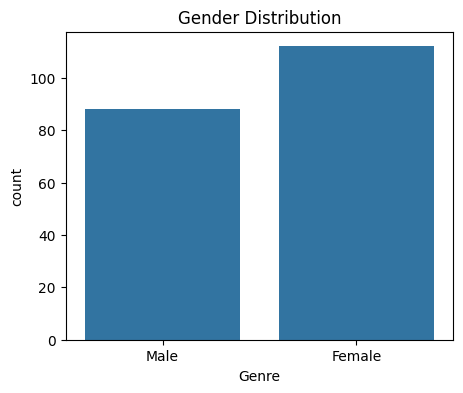

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='Genre', data=df)
plt.title("Gender Distribution")
plt.show()

## Age Distribution

This histogram shows the age distribution of customers.

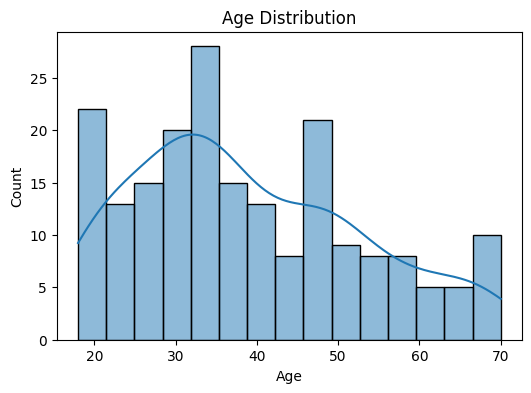

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=15, kde=True)
plt.title("Age Distribution")
plt.show()

## Annual Income Distribution

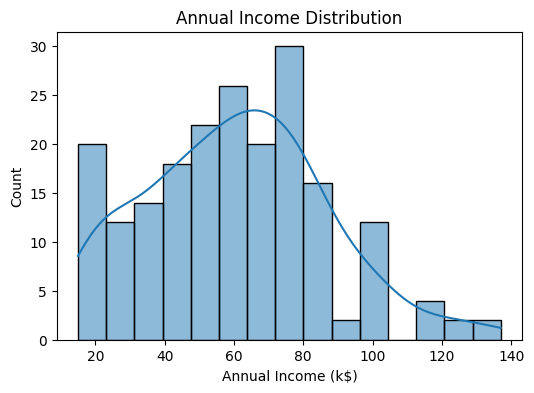

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=15, kde=True)
plt.title("Annual Income Distribution")
plt.show()

## Spending Score Distribution

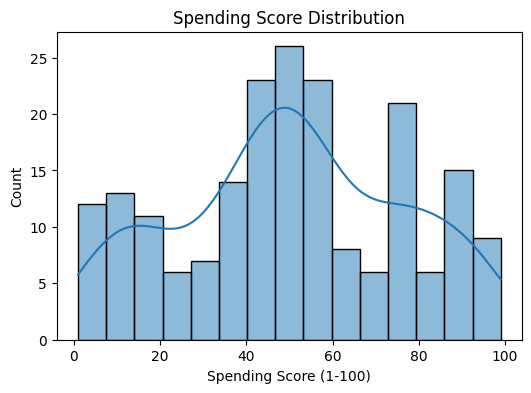

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True)
plt.title("Spending Score Distribution")
plt.show()

## Feature Selection

We will use Annual Income and Spending Score for customer segmentation.

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Scatter Plot

Visualizing customer distribution.

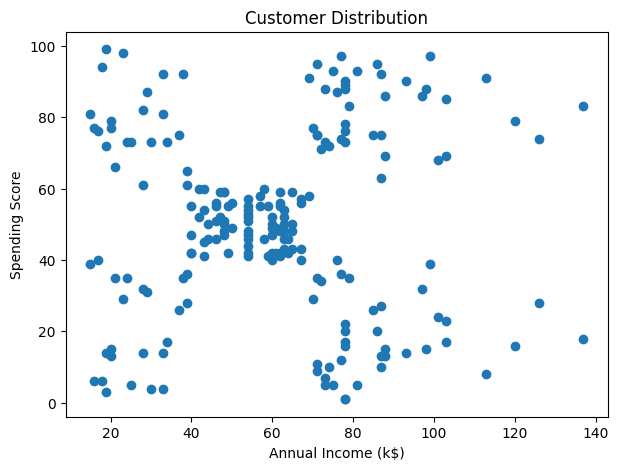

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

## Finding Optimal Number of Clusters (Elbow Method)

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    random_state=42)

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

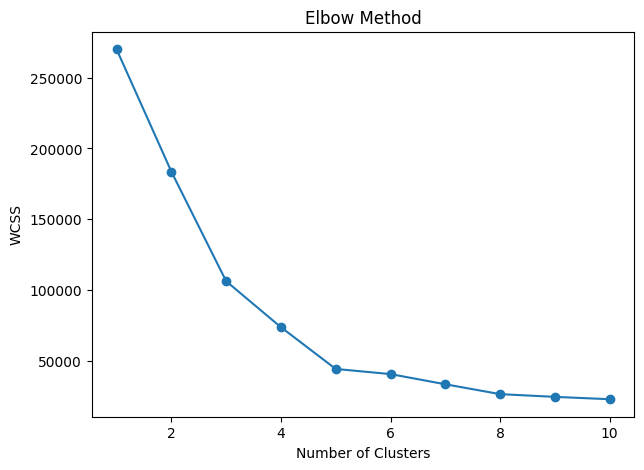

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

In [ ]:
print(y_kmeans)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [ ]:
df["Cluster"] = y_kmeans

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
df["Cluster"].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


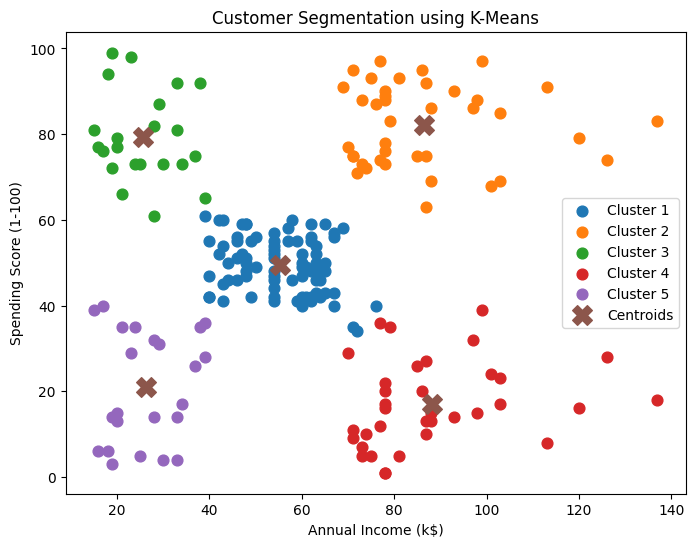

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X.loc[y_kmeans==0, 'Annual Income (k$)'],
    X.loc[y_kmeans==0, 'Spending Score (1-100)'],
    s=60, label='Cluster 1'
)

plt.scatter(
    X.loc[y_kmeans==1, 'Annual Income (k$)'],
    X.loc[y_kmeans==1, 'Spending Score (1-100)'],
    s=60, label='Cluster 2'
)

plt.scatter(
    X.loc[y_kmeans==2, 'Annual Income (k$)'],
    X.loc[y_kmeans==2, 'Spending Score (1-100)'],
    s=60, label='Cluster 3'
)

plt.scatter(
    X.loc[y_kmeans==3, 'Annual Income (k$)'],
    X.loc[y_kmeans==3, 'Spending Score (1-100)'],
    s=60, label='Cluster 4'
)

plt.scatter(
    X.loc[y_kmeans==4, 'Annual Income (k$)'],
    X.loc[y_kmeans==4, 'Spending Score (1-100)'],
    s=60, label='Cluster 5'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [ ]:
df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [ ]:
df.groupby("Cluster").size()

,0
Cluster,
0,81
1,39
2,22
3,35
4,23


## Conclusion

- Successfully performed customer segmentation using K-Means Clustering.
- Explored and analyzed the dataset using EDA.
- Selected Annual Income and Spending Score as features.
- Used the Elbow Method to determine the optimal number of clusters.
- Segmented customers into 5 distinct groups.
- Visualized clusters and centroids for better business understanding.
- This project can help businesses design targeted marketing strategies.